## selecting libraries

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## getting dataset

In [85]:
import pandas as pd

california = pd.read_csv(
    "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"
)

print(california.head())


   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


## getting columns

In [86]:
california.keys()

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

In [87]:
california.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [88]:
 df= california

In [89]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [90]:
df.drop('ocean_proximity', axis=1, inplace=True)

In [91]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
dtype: int64

In [92]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(
    df['total_bedrooms'].mean(),
    inplace=True
)

/var/folders/dd/62sfblkd4_j6t6_2jd5p64940000gn/T/ipykernel_45869/2504622789.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['total_bedrooms'] = df['total_bedrooms'].fillna(


In [93]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64

## finding correlation


In [94]:
 df.corr()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069260,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066658,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.318998,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.927253,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069260,-0.066658,-0.318998,0.927253,1.000000,0.873910,0.974725,-0.007682,0.049454
population,0.099773,-0.108785,-0.296244,0.857126,0.873910,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.974725,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007682,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049454,-0.024650,0.065843,0.688075,1.000000


## creating its heatmap

<Axes: >

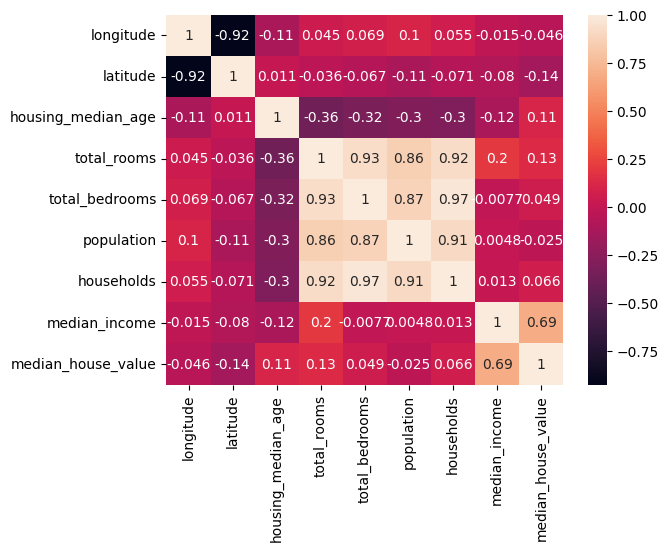

In [95]:
import seaborn as sns
sns.heatmap(df.corr(numeric_only=True), annot=True)

## div indep and dep feaatures

In [96]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [97]:
x.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462


In [98]:
y.head()

0    452600.0
1    358500.0
2    352100.0
3    341300.0
4    342200.0
Name: median_house_value, dtype: float64

## train_test_split

In [101]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.33, random_state=42)

In [102]:
x_train.shape

(13828, 8)

## standerdize

In [104]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test =scaler.transform(x_test)

In [105]:
x_train

array([[ 0.65090402, -0.78315293, -0.75868455, ..., -0.61496167,
        -0.58566358, -1.52169954],
       [-1.31911678,  0.8475975 ,  0.3523991 , ..., -0.36282305,
        -0.19465717,  0.18205382],
       [ 0.66087881, -0.87218816,  1.06666717, ..., -0.33752194,
        -0.67950512, -0.17232772],
       ...,
       [ 0.60103008, -0.75972261,  0.59048846, ...,  0.28366387,
         0.06601377, -0.49518065],
       [-1.18445713,  0.90383028, -1.07613702, ...,  0.30198536,
         0.14942847,  0.96816708],
       [-1.41387727,  0.9928655 ,  1.86029835, ...,  1.03658993,
         1.92981097, -0.68377427]], shape=(13828, 8))

In [106]:
x_test

array([[ 0.28682423,  0.19154848, -0.28250584, ..., -0.03390865,
        -0.37191341, -1.15370815],
       [ 0.06239148, -0.23956945,  0.11430975, ...,  0.11702554,
         0.2145962 , -0.70700034],
       [-1.42385206,  1.0069237 ,  1.86029835, ..., -0.10544971,
         1.20253906, -0.20842797],
       ...,
       [-0.90516304,  1.43335556, -1.07613702, ...,  1.04269709,
         0.59256906, -0.02167353],
       [ 1.09478213, -0.73160623, -1.47295261, ...,  1.82964878,
         1.12173107,  0.27275111],
       [-1.43881424,  0.99755157,  1.78093523, ..., -0.48060407,
        -0.30413897, -0.59570436]], shape=(6812, 8))

## appply linear regression

In [110]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()

regression

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [112]:
regression.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [113]:
regression.coef_

array([-85752.99554225, -90509.84220459,  14729.77890525, -17651.73965666,
        50776.22547848, -42354.172638  ,  14339.88322666,  76679.34645409])

In [114]:
regression.intercept_

np.float64(206663.62048018535)

## prediction for the test data

In [115]:
y_pred = regression.predict(x_test)

In [116]:
y_pred

array([ 77205.17885571, 165898.63960629, 260856.56229688, ...,
       111098.17274481, 140493.56524165, 227161.1440258 ], shape=(6812,))

## performance metrics

In [119]:
from sklearn.metrics import mean_squared_error, mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R-squared:", r2)
print("Root Mean Squared Error:", np.sqrt(mse))

Mean Squared Error: 4912846454.722854
Mean Absolute Error: 51273.28335277229
R-squared: 0.6313314851102001
Root Mean Squared Error: 70091.70032694923


## assumption

Text(0, 0.5, 'predicted data')

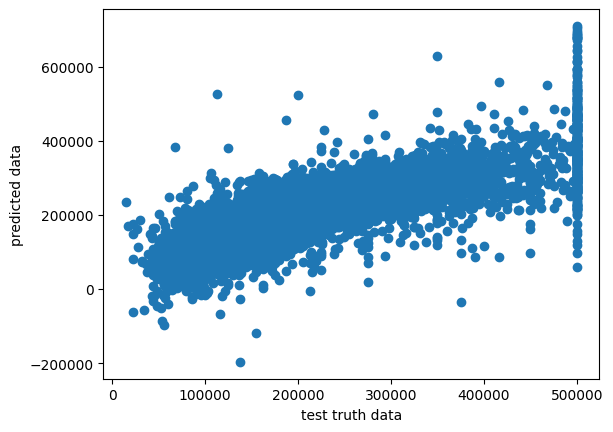

In [120]:
plt.scatter(y_test,y_pred)
plt.xlabel('test truth data')
plt.ylabel('predicted data')

In [122]:
residuals = y_test - y_pred

residuals

20046    -29505.178856
3024    -120098.639606
15663    239144.437703
20484    -56742.784208
9814      -1069.338340
             ...      
15316     48466.773079
14772    -62680.044186
12870     -4098.172745
13476     -9793.565242
16123     79938.855974
Name: median_house_value, Length: 6812, dtype: float64

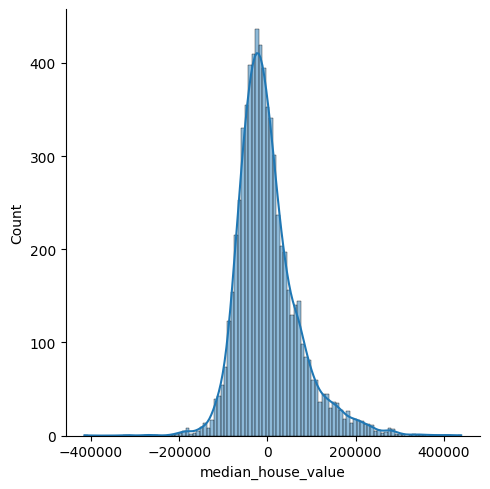

In [123]:
sns.displot(residuals, kde=True)

### scatter plot with prediction and residual
### unform distribution

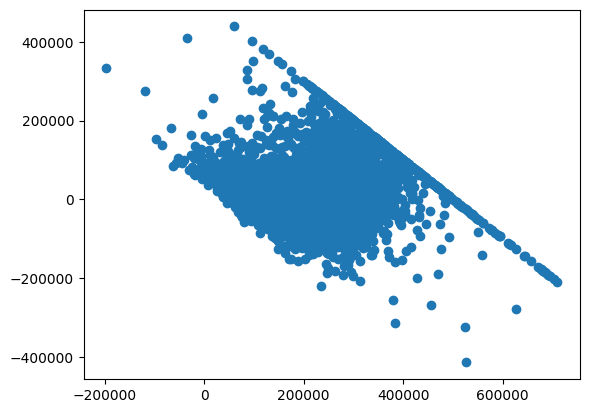

In [124]:
plt.scatter(y_pred,residuals)

## importing pickle file

In [126]:
import pickle
pickle.dump(regression, open('regression.pkl', 'wb'))

In [128]:
model=pickle.load(open('regression.pkl', 'rb',))

In [129]:
model.predict(x_test)

array([ 77205.17885571, 165898.63960629, 260856.56229688, ...,
       111098.17274481, 140493.56524165, 227161.1440258 ], shape=(6812,))